In [ ]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import *

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
eps = 1e-12
inc_ang = 30.*(np.pi/180) + eps   # radian
azi_ang = 0.*(np.pi/180) + eps   # radian

pec_eps = torch.tensor(-10000.0 + 0.0j, dtype=sim_dtype, device=device)

order_N = 40
# geometry
h = 1000 #nm
grating_period = 1000 # nm
nx = 20000

x_plot = torch.linspace(0,grating_period,501,device=device)
z_plot = torch.linspace(-h,1.5*h,501,device=device)

wavelength = 600
wavelengths = torch.linspace(300, 1100, 101, dtype=int)

#Sanity check of staircase approximation
num_layers = 50
params = torch.tensor([[40,-np.pi/2]], dtype=geo_dtype, device=device)

## Testing and plotting

In [2]:
wavelengths

tensor([ 300,  308,  316,  324,  332,  340,  348,  356,  364,  372,  380,  388,
         396,  404,  412,  420,  428,  436,  444,  452,  460,  468,  476,  484,
         492,  500,  508,  516,  524,  532,  540,  548,  556,  564,  572,  580,
         588,  596,  604,  612,  620,  628,  636,  644,  652,  660,  668,  676,
         684,  692,  700,  708,  716,  724,  732,  740,  748,  756,  764,  772,
         780,  788,  796,  804,  812,  820,  828,  836,  844,  852,  860,  868,
         876,  884,  892,  900,  908,  916,  924,  932,  940,  948,  956,  964,
         972,  980,  988,  996, 1004, 1012, 1020, 1028, 1036, 1044, 1052, 1060,
        1068, 1076, 1084, 1092, 1100])

In [3]:
sim, sine_eps,A_film, A_grating,A_reflector, Reflectance, Transmittance, P_abs_film, P_abs_grating,P_abs_reflector, P_slices \
    = get_absorptance(params,wavelength,inc_ang,azi_ang,grating_period,h,order_N,n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='pec')

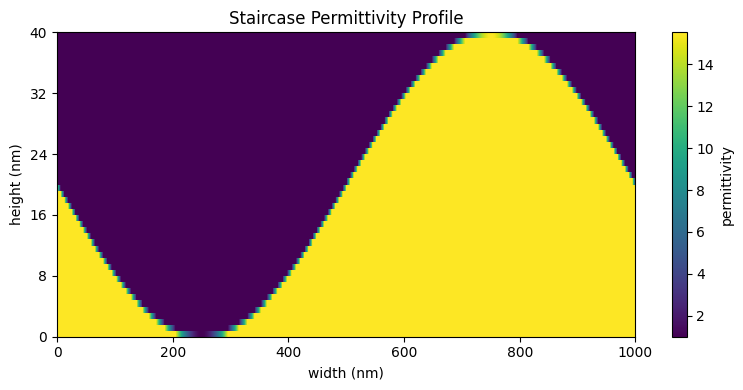

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
x_min_nm = x_plot.min().item()
x_max_nm = x_plot.max().item()
y_min_nm = 0.0
y_max_nm = float(sum(params[:,0]))

im = ax.imshow(
    sine_eps.cpu().abs().T,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    interpolation='none',
    extent=[x_min_nm, x_max_nm, y_min_nm, y_max_nm],
)

ax.set_xticks(np.linspace(x_min_nm, x_max_nm, 6))
ax.set_yticks(np.linspace(y_min_nm, y_max_nm, 6))
ax.set_xlabel('width (nm)')
ax.set_ylabel('height (nm)')
ax.set_title('Staircase Permittivity Profile')
fig.colorbar(im, ax=ax, label='permittivity')
plt.tight_layout()
plt.show()

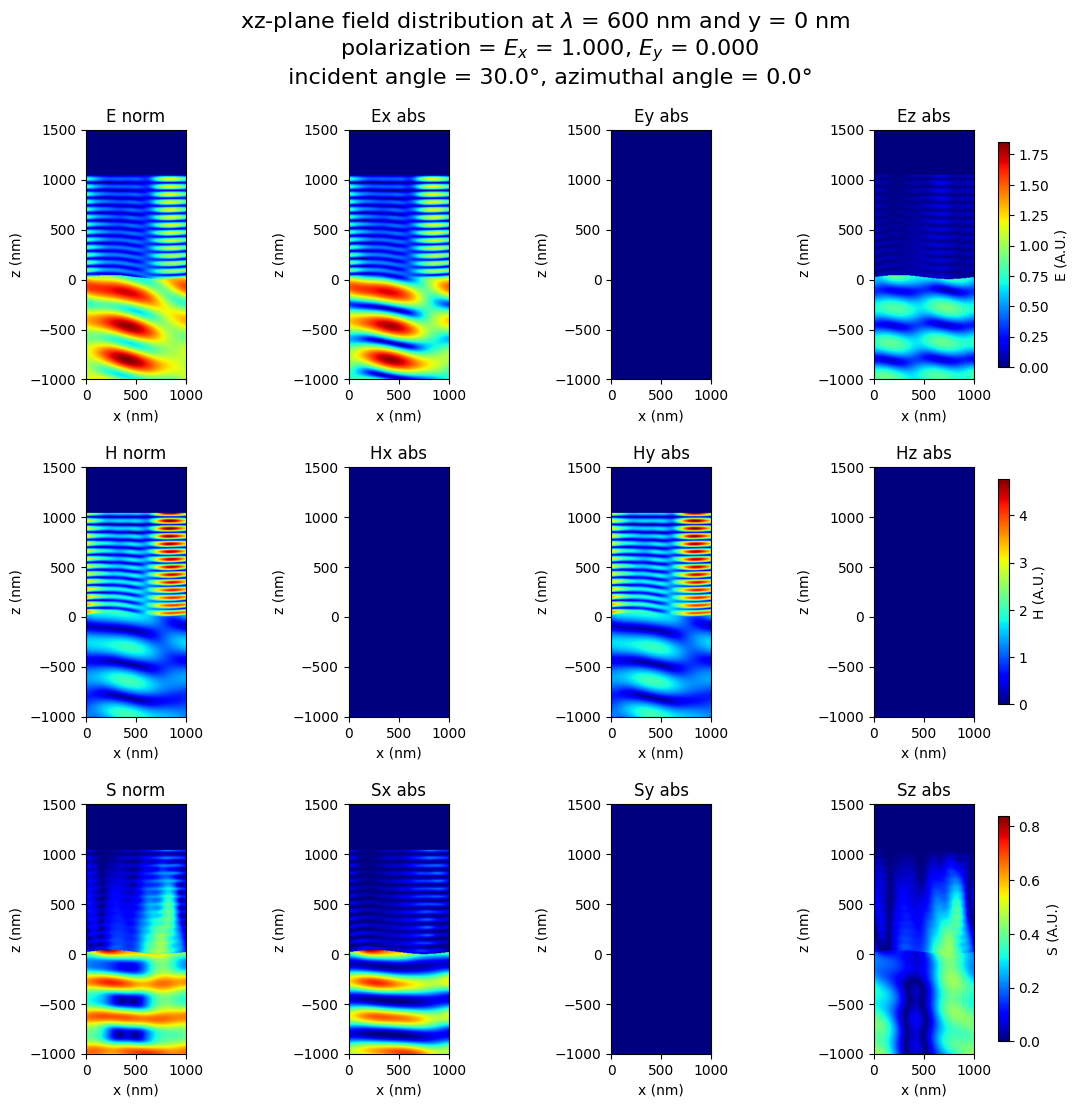

In [5]:
polarization = [1,0]
plot_fields(sim,x_plot,z_plot,wavelength,polarization,inc_ang,azi_ang)

In [6]:
A_film,A_grating,A_reflector

(tensor([0.4922, 0.4337], device='cuda:0'),
 tensor([0.0117, 0.0101], device='cuda:0'),
 tensor([-1.7125e-07, -1.3045e-07], device='cuda:0'))

## Absorptance curves

### Num layers

In [ ]:
layer_counts = [1, 5, 10, 20, 50, 100, 250]
simulation_results = {}

for num_layers in layer_counts:
    print(f'simulating absorptance curve for {num_layers} layers')
    absorptances = get_absorptance_curve(params,wavelengths,inc_ang,azi_ang,grating_period,h,order_N,\
        n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='pec')

    simulation_results[num_layers] = {
        'absorptances': absorptances.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_num_layers.pt')

simulating absorptance curve for 1 layers


100%|██████████| 101/101 [00:06<00:00, 14.58it/s]


simulating absorptance curve for 5 layers


100%|██████████| 101/101 [00:15<00:00,  6.66it/s]


simulating absorptance curve for 10 layers


...

100%|██████████| 101/101 [02:01<00:00,  1.20s/it]


simulating absorptance curve for 100 layers


100%|██████████| 101/101 [04:23<00:00,  2.61s/it]


simulating absorptance curve for 250 layers


 93%|█████████▎| 94/101 [13:03<00:58,  8.32s/it]

In [ ]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_num_layers.pt', weights_only=False)
layer_counts = sorted(list(results.keys()))

best_layer_count = layer_counts[-1]
best_abs = results[best_layer_count]['absorptances']

# Create a 1x2 grid of subplots for p and s
fig, (ax1_p, ax1_s) = plt.subplots(1, 2, figsize=(14, 6))

# Twin axes for both subplots
ax2_p = ax1_p.twinx()
ax2_s = ax1_s.twinx()

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[num_layers]['absorptances']
    
    # Primary axis: Absorptance (Index 0 is p-pol/TM, Index 1 is s-pol/TE)
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0], label=f'{num_layers} Layers', color=colors[idx], linewidth=1.2, alpha=0.9)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1], label=f'{num_layers} Layers', color=colors[idx], linewidth=1.2, alpha=0.9)
    
    # Secondary axis: Relative Error (skip the baseline itself)
    if num_layers != best_layer_count:
        rel_error_p = np.abs((curr_abs[:, 0] - best_abs[:, 0]) / (best_abs[:, 0] + 1e-12))
        rel_error_s = np.abs((curr_abs[:, 1] - best_abs[:, 1]) / (best_abs[:, 1] + 1e-12))
        
        # Using dotted lines for the error to distinguish from the main curves
        ax2_p.plot(wavelengths.cpu(), rel_error_p, color=colors[idx], linestyle=':', alpha=0.7)
        ax2_s.plot(wavelengths.cpu(), rel_error_s, color=colors[idx], linestyle=':', alpha=0.7)

# Format p-Polarization Plot
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax2_p.set_ylabel(f'Relative Error (vs {best_layer_count} Layers)', color='gray')
ax1_p.set_title(f'p-Polarization\nIncident angle is {inc_ang*180/np.pi:.2f}, azimuthal angle is {azi_ang*180/np.pi:.2f}')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best')
ax1_p.set_yscale('log')
ax2_p.set_yscale('log')

# Format s-Polarization Plot
ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax2_s.set_ylabel(f'Relative Error (vs {best_layer_count} Layers)', color='gray')
ax1_s.set_title(f's-Polarization\nIncident angle is {inc_ang*180/np.pi:.2f}, azimuthal angle is {azi_ang*180/np.pi:.2f}')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best')
ax1_s.set_yscale('log')
ax2_s.set_yscale('log')

fig.tight_layout()
plt.show()

/tmp/ipykernel_124824/677493937.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rel_error = np.abs((curr_abs - best_abs) / (best_abs + 1e-12))


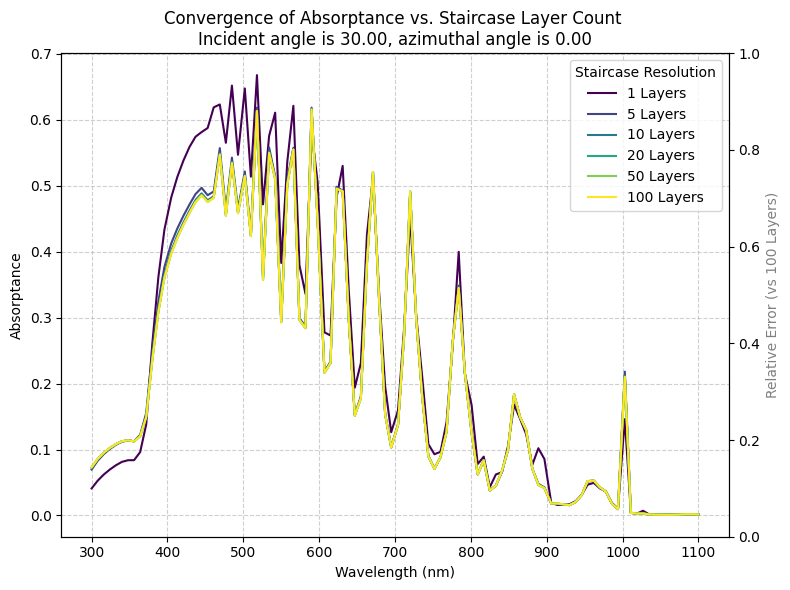

In [ ]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_num_layers.pt', weights_only=False)
layer_counts = sorted(list(results.keys()))

best_layer_count = layer_counts[-1]
best_abs = results[best_layer_count]['absorptances']

fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[num_layers]['absorptances']
    
    # Primary axis: Absorptance
    ax1.plot(wavelengths.cpu(), curr_abs, label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5,alpha=1)
    
    # Secondary axis: Relative Error (skip the baseline itself)
    if num_layers != best_layer_count:
        rel_error = np.abs((curr_abs - best_abs) / (best_abs + 1e-12))
        # Using dotted lines for the error to distinguish from the main curves
       # ax2.plot(wavelengths, rel_error, color=colors[idx], linestyle=':', alpha=0.7)

ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Absorptance')
#ax2.set_ylabel(f'Relative Error (vs {best_layer_count} Layers)', color='gray')
ax1.set_title(f'Convergence of Absorptance vs. Staircase Layer Count \nIncident angle is {inc_ang*180/np.pi:.2f}, azimuthal angle is {azi_ang*180/np.pi:.2f}')

ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(title='Staircase Resolution', loc='best')
ax1.set_yscale('log')
#ax2.set_yscale('log')
fig.tight_layout()
plt.show()

### Fourier Order

In [ ]:
Order_Ns = [1, 5, 10, 20, 40, 50, 100, 250]
simulation_results = {}
num_layers = 50

for order_N in Order_Ns:
    print(f'simulating absorptance curve for {num_layers} layers')
    absorptances = get_absorptance_curve(params,wavelengths,inc_ang,azi_ang,grating_period,h,order_N,\
        n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='pec')

    simulation_results[num_layers] = {
        'absorptances': absorptances.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_order_N.pt')

In [ ]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_order_N.pt', weights_only=False)
order_Ns = sorted(list(results.keys()))

best_order = order_Ns[-1]
best_abs = results[best_order]['absorptances']

fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()

colors = plt.cm.viridis(np.linspace(0, 1, len(order_Ns)))

for idx, order in enumerate(order_Ns):
    curr_abs = results[order]['absorptances']
    
    # Primary axis: Absorptance
    ax1.plot(wavelengths.cpu(), curr_abs, label=f'Fourer order: {order} ', color=colors[idx], linewidth=1.5,alpha=1)
    
    # Secondary axis: Relative Error (skip the baseline itself)
    if order != best_order:
        rel_error = np.abs((curr_abs - best_abs) / (best_abs + 1e-12))
        # Using dotted lines for the error to distinguish from the main curves
       # ax2.plot(wavelengths, rel_error, color=colors[idx], linestyle=':', alpha=0.7)

ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Absorptance')
ax2.set_ylabel(f'Relative Error (vs {best_order} Layers)', color='gray')
ax1.set_title(f'Convergence of Absorptance vs. Staircase Layer Count \nIncident angle is {inc_ang*180/np.pi:.2f}, azimuthal angle is {azi_ang*180/np.pi:.2f}')

ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(title='Staircase Resolution', loc='best')
#ax1.set_yscale('log')
#ax2.set_yscale('log')
fig.tight_layout()
plt.show()